In [139]:
#Author: Maciej Brzozowski

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uncertainties import ufloat
from uncertainties.umath import sqrt
from odrpack import odr_fit
%matplotlib inline
plt.ion()

In [141]:
multimetr_error=0.1*3 #cyfry
multimetr_rel_error=0.008

def error(data, instrument_error):
    if len(data)==1:
        return instrument_error
    stat_error = np.std(data, ddof=1) / np.sqrt(len(data))
    return np.sqrt(stat_error**2+(instrument_error)**2)

def process(data,instrument_error):
    return ufloat(np.mean(data),error(data,instrument_error))

def printer(*args):
    print(*('{:.2u}'.format(x) for x in args))
    print(*('{:.2uL}'.format(x) for x in args))

In [142]:
R_1 = ufloat(10.6,10.6*multimetr_rel_error+multimetr_error)
R_2 = ufloat(10.4,10.4*multimetr_rel_error+multimetr_error)
R_C = ufloat(100.1,100.1*multimetr_rel_error+multimetr_error)
R_Ni = ufloat(113.6,113.6*multimetr_rel_error+multimetr_error)
R_Pt = ufloat(109.3,109.3*multimetr_rel_error+multimetr_error)

printer(R_1,R_2,R_C,R_Ni,R_Pt)

10.60+/-0.38 10.40+/-0.38 100.1+/-1.1 113.6+/-1.2 109.3+/-1.2
10.60 \pm 0.38 10.40 \pm 0.38 100.1 \pm 1.1 113.6 \pm 1.2 109.3 \pm 1.2


In [143]:
R1overR2 = R_1/R_2
printer(R1overR2) 

1.019+/-0.053
1.019 \pm 0.053


In [144]:
df = pd.read_csv("data_ogrzewanie.csv")
df.head()

,T,R_C,R_Ni,R_Pt
0,24,102.0,116.0,111.0
1,25,102.0,118.0,NaN
2,26,NaN,NaN,115.0
3,27,102.0,120.0,NaN
4,28,NaN,NaN,116.0


In [145]:
def analise_data(T_pomiary,R_pomiary,T_error,R_error):
    
    def f(x: np.ndarray,beta: np.ndarray) -> np.ndarray:
        a,b= beta
        return a*x+b
    beta0 = [0.6,105.0]
    sol = odr_fit(f,T_pomiary,R_pomiary,beta0,weight_x=T_error**-2,weight_y=R_error**-2)
    a,b=sol.beta
    a_err,b_err = sol.sd_beta

    return a,b,a_err,b_err

In [146]:
df_Ni = df[["T","R_Ni"]]
df_Ni = df_Ni.dropna()
T_Ni_pomiary = df_Ni["T"].to_numpy()
T_Ni_error = 0.5
R_Ni_pomiary = df_Ni["R_Ni"].to_numpy()
R_Ni_error = 1
a_Ni,b_Ni,a_Ni_err,b_Ni_err = analise_data(T_Ni_pomiary,R_Ni_pomiary,T_Ni_error,R_Ni_error)
print(a_Ni,b_Ni,a_Ni_err,b_Ni_err)



0.5771612770690979 102.91178770543571 0.006522595894029227 0.41533118745929676


In [147]:
df_Pt = df[["T","R_Pt"]]
df_Pt = df_Pt.dropna()
T_Pt_pomiary = df_Pt["T"].to_numpy()
T_Pt_error = 0.5
R_Pt_pomiary = df_Pt["R_Pt"].to_numpy()
R_Pt_error = 1
a_Pt,b_Pt,a_Pt_err,b_Pt_err = analise_data(T_Pt_pomiary,R_Pt_pomiary,T_Pt_error,R_Pt_error)
print(a_Pt,b_Pt,a_Pt_err,b_Pt_err)

0.36395799822561975 104.58140793237598 0.005564969049159279 0.3556015652723515


In [148]:
df_C = df[["T","R_C"]]
df_C = df_C.dropna()
T_C_pomiary = df_C["T"].to_numpy()
T_C_error = 0.5
R_C_pomiary = df_C["R_C"].to_numpy()
R_C_error = 1
a_C,b_C,a_C_err,b_C_err = analise_data(T_C_pomiary,R_C_pomiary,T_C_error,R_C_error)
print(a_C,b_C,a_C_err,b_C_err)




2.657742627298018e-07 101.9999836052508 3.5262653325708274e-09 7.3551698274555e-07


0.00518+/-0.00028
0.00339+/-0.00019
(2.71+/-0.15)e-09


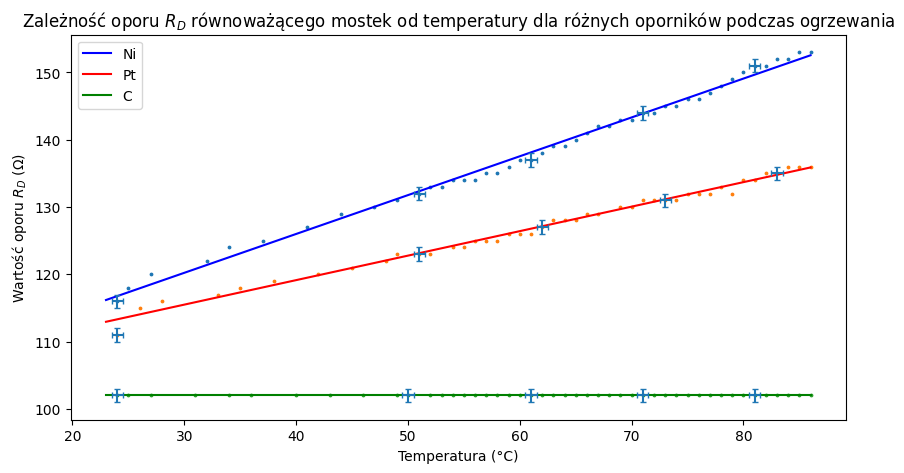

In [149]:
fig, ax = plt.subplots(figsize=(10, 5))
x_fit = np.linspace(23, 86, 100)
ax.scatter(T_Ni_pomiary, R_Ni_pomiary,s=3)
ax.plot(x_fit, a_Ni * x_fit + b_Ni , 'b-',label="Ni")
ax.errorbar(T_Ni_pomiary[::10],R_Ni_pomiary[::10],xerr=T_Ni_error,yerr=R_Ni_error,fmt="None",capsize=2)

print(ufloat(a_Ni,a_Ni_err)*R1overR2/R_Ni)


ax.scatter(T_Pt_pomiary, R_Pt_pomiary,s=3)
ax.plot(x_fit, a_Pt * x_fit + b_Pt, 'r-',label="Pt")
ax.errorbar(T_Pt_pomiary[::10],R_Pt_pomiary[::10],xerr=T_Pt_error,yerr=R_Pt_error,fmt="None",capsize=2)

print(ufloat(a_Pt,a_Pt_err)*R1overR2/R_Pt)


ax.scatter(T_C_pomiary, R_C_pomiary,s=3)
ax.plot(x_fit, a_C * x_fit + b_C, 'g-',label="C")
ax.errorbar(T_C_pomiary[::10],R_C_pomiary[::10],xerr=T_C_error,yerr=R_C_error,fmt="None",capsize=2)
ax.legend()
ax.set_xlabel("Temperatura (\N{DEGREE SIGN}C)")
ax.set_ylabel("Wartość oporu $R_D$ ($\Omega$)")
ax.set_title("Zależność oporu $R_D$ równoważącego mostek od temperatury dla różnych oporników podczas ogrzewania")
print(ufloat(a_C,a_C_err)*R1overR2/R_C)
plt.show()

In [150]:
df = pd.read_csv("data_ochladzanie.csv")
df.head()

,T,R_C,R_Ni,R_Pt
0,86,NaN,NaN,134.0
1,85,NaN,NaN,NaN
2,84,NaN,NaN,NaN
3,83,NaN,NaN,NaN
4,82,NaN,NaN,NaN


In [151]:
df_Ni = df[["T","R_Ni"]]
df_Ni = df_Ni.dropna()
T_Ni_pomiary = df_Ni["T"].to_numpy()
T_Ni_error = 0.5
R_Ni_pomiary = df_Ni["R_Ni"].to_numpy()
R_Ni_error = 1
a_Ni,b_Ni,a_Ni_err,b_Ni_err = analise_data(T_Ni_pomiary,R_Ni_pomiary,T_Ni_error,R_Ni_error)
print(a_Ni,b_Ni,a_Ni_err,b_Ni_err)


0.5817358120843288 102.74354002920647 0.008054551564073382 0.4890959386436638


In [152]:
df_Pt = df[["T","R_Pt"]]
df_Pt = df_Pt.dropna()
T_Pt_pomiary = df_Pt["T"].to_numpy()
T_Pt_error = 0.5
R_Pt_pomiary = df_Pt["R_Pt"].to_numpy()
R_Pt_error = 1
a_Pt,b_Pt,a_Pt_err,b_Pt_err = analise_data(T_Pt_pomiary,R_Pt_pomiary,T_Pt_error,R_Pt_error)
print(a_Pt,b_Pt,a_Pt_err,b_Pt_err)

0.37714266504946603 102.67463361812831 0.005237005540720584 0.3259183361902316


In [153]:
df_C = df[["T","R_C"]]
df_C = df_C.dropna()
T_C_pomiary = df_C["T"].to_numpy()
T_C_error = 0.5
R_C_pomiary = df_C["R_C"].to_numpy()
R_C_error = 1
a_C,b_C,a_C_err,b_C_err = analise_data(T_C_pomiary,R_C_pomiary,T_C_error,R_C_error)
print(a_C,b_C,a_C_err,b_C_err)


-6.885467739436939e-07 102.00004053100304 1.5976346741230904e-08 1.8369042234985188e-06


0.00522+/-0.00028
0.00352+/-0.00019
(-7.0+/-0.4)e-09


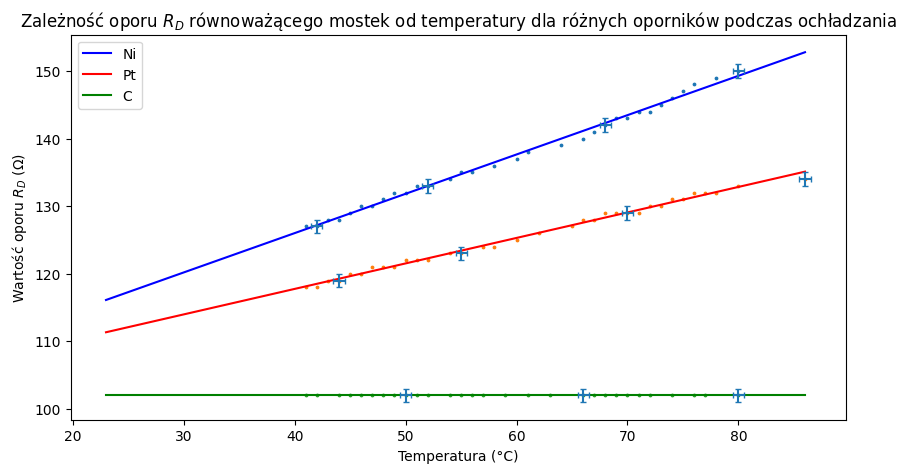

In [154]:
fig, ax = plt.subplots(figsize=(10, 5))
x_fit = np.linspace(23, 86, 100)
ax.scatter(T_Ni_pomiary, R_Ni_pomiary,s=3)
ax.plot(x_fit, a_Ni * x_fit + b_Ni , 'b-',label="Ni")
ax.errorbar(T_Ni_pomiary[::10],R_Ni_pomiary[::10],xerr=T_Ni_error,yerr=R_Ni_error,fmt="None",capsize=2)

print(ufloat(a_Ni,a_Ni_err)*R1overR2/R_Ni)


ax.scatter(T_Pt_pomiary, R_Pt_pomiary,s=3)
ax.plot(x_fit, a_Pt * x_fit + b_Pt, 'r-',label="Pt")
ax.errorbar(T_Pt_pomiary[::10],R_Pt_pomiary[::10],xerr=T_Pt_error,yerr=R_Pt_error,fmt="None",capsize=2)

print(ufloat(a_Pt,a_Pt_err)*R1overR2/R_Pt)


ax.scatter(T_C_pomiary, R_C_pomiary,s=3)
ax.plot(x_fit, a_C * x_fit + b_C, 'g-',label="C")
ax.errorbar(T_C_pomiary[::10],R_C_pomiary[::10],xerr=T_C_error,yerr=R_C_error,fmt="None",capsize=2)
ax.legend()
ax.set_xlabel("Temperatura (\N{DEGREE SIGN}C)")
ax.set_ylabel("Wartość oporu $R_D$ ($\Omega$)")
ax.set_title("Zależność oporu $R_D$ równoważącego mostek od temperatury dla różnych oporników podczas ochładzania")
print(ufloat(a_C,a_C_err)*R1overR2/R_C)
plt.show()

In [158]:
R_T_Ni = 153
alpha_Ni = (R_T_Ni - R_Ni)/(R_Ni*(86-23))
print(alpha_Ni)
R_T_Pt = 136
alpha_Pt = (R_T_Pt - R_Pt)/(R_Pt*(86-23))
print(alpha_Pt)
R_T_C = 102
alpha_C = (R_T_C - R_C)/(R_C*(86-23))
print(alpha_C)

0.00551+/-0.00023
0.00388+/-0.00021
0.00030+/-0.00018
